In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from scipy import stats
import matplotlib.pyplot as plt

# Part 1: US presidential election information
Creating a table of US presidential election dates (2000-2024) with winning party and candidate names.

In [2]:
elections_data = {
    'date': pd.to_datetime([
        '2000-11-07',
        '2004-11-02',
        '2008-11-04',
        '2012-11-06',
        '2016-11-08',
        '2020-11-03',
        '2024-11-05'
    ]),

    'party': [
        'Republican',
        'Republican',
        'Democratic',
        'Democratic',
        'Republican',
        'Democratic',
        'Republican'
    ],

    'winner': [
        'George W. Bush',
        'George W. Bush',
        'Barack Obama',
        'Barack Obama',
        'Donald Trump',
        'Joe Biden',
        'Donald Trump'
    ],
}

elections_df = pd.DataFrame(elections_data)
elections_df['is_election'] = True
print(elections_df)

        date       party          winner  is_election
0 2000-11-07  Republican  George W. Bush         True
1 2004-11-02  Republican  George W. Bush         True
2 2008-11-04  Democratic    Barack Obama         True
3 2012-11-06  Democratic    Barack Obama         True
4 2016-11-08  Republican    Donald Trump         True
5 2020-11-03  Democratic       Joe Biden         True
6 2024-11-05  Republican    Donald Trump         True


# Part 2: Downloading data from Yahoo Finance
- **S&P 500** (stock market index) - daily closing prices
- **VIX** (volatility index) - daily closing prices


Both cover period from January 2000 to December 2025.

In [3]:
sp500 = yf.download("^GSPC", start="2000-01-01", end="2025-12-31")
sp500 = sp500.reset_index()
sp500 = sp500[['Date', 'Close']]
sp500.columns = ['date', 'sp500_value']

print(f"\n{len(sp500)} key points with S&P 500 data")

/tmp/ipykernel_7355/2581326773.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2000-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


6538 key points with S&P 500 data


In [4]:
vix = yf.download("^VIX", start="2000-01-01", end="2025-12-31")
vix = vix.reset_index()
vix = vix[['Date', 'Close']]
vix.columns = ['date', 'vix_value']

print(f"\n{len(vix)} key points with VIX data")

/tmp/ipykernel_7355/666543744.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  vix = yf.download("^VIX", start="2000-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


6538 key points with VIX data


# Part 3: Merge and Calculate returns
1. **Election DataFrame:** Copies election data, creates an `event_label` combining party and winner name

2. **Market DataFrame:** Merges S&P 500 and VIX on dates, sorts chronologically

3. **Returns:** Calculates daily percentage changes for both indices

4. **Election flags:** Marks rows where date matches any US presidential election date

In [5]:
election_df = elections_df.copy()
election_df['date'] = election_df['date']
election_df['is_election'] = True
election_df['event_label'] = election_df['party'] + " (" + election_df['winner'] + ")"

market_df = pd.merge(sp500, vix, on='date', how='inner')
market_df = market_df.sort_values('date').reset_index(drop=True)

market_df['sp500_return'] = market_df['sp500_value'].pct_change()
market_df['vix_return'] = market_df['vix_value'].pct_change()

election_dates = elections_df['date']

market_df['is_election'] = market_df['date'].isin(election_dates)

print(market_df.head())
print(len(market_df))
print(market_df['is_election'].sum())

        date  sp500_value  vix_value  sp500_return  vix_return  is_election
0 2000-01-03  1455.219971  24.209999           NaN         NaN        False
1 2000-01-04  1399.420044  27.010000     -0.038345    0.115655        False
2 2000-01-05  1402.109985  26.410000      0.001922   -0.022214        False
3 2000-01-06  1403.449951  25.730000      0.000956   -0.025748        False
4 2000-01-07  1441.469971  21.719999      0.027090   -0.155849        False
6538
7


# Part 4: Sample Separation

At this stage I construct event windows around each presidential election date to analyze market behavior before and after elections separatly.

4  samples:

- 10 days before and after the election
- 30 days before and after the election


Election days themselves are excluded from all samples to avoid mixing  event with surrounding periods.




In [6]:
election_dates = elections_df['date']

pre_10_list = []
post_10_list = []
pre_30_list = []
post_30_list = []


for event_date in election_dates:

    temp = market_df.copy()

    temp['days_from_event'] = (temp['date'] - event_date).dt.days

    pre_10 = temp[
        (temp['days_from_event'] >= -10) &
        (temp['days_from_event'] < 0)
    ]
    pre_10_list.append(pre_10)

    post_10 = temp[
        (temp['days_from_event'] > 0) &
        (temp['days_from_event'] <= 10)
    ]
    post_10_list.append(post_10)

    pre_30 = temp[
        (temp['days_from_event'] >= -30) &
        (temp['days_from_event'] < 0)
    ]
    pre_30_list.append(pre_30)

    post_30 = temp[
        (temp['days_from_event'] > 0) &
        (temp['days_from_event'] <= 30)
    ]
    post_30_list.append(post_30)


pre_10_df = pd.concat(pre_10_list, ignore_index=True)
post_10_df = pd.concat(post_10_list, ignore_index=True)
pre_30_df = pd.concat(pre_30_list, ignore_index=True)
post_30_df = pd.concat(post_30_list, ignore_index=True)


event_dates_all = pd.concat([
    pre_10_df['date'],
    post_10_df['date'],
    pre_30_df['date'],
    post_30_df['date']
]).unique()

control_df = market_df[~market_df['date'].isin(event_dates_all)].copy()
control_df = control_df.dropna()

print(control_df)

           date  sp500_value  vix_value  sp500_return  vix_return  is_election
1    2000-01-04  1399.420044  27.010000     -0.038345    0.115655        False
2    2000-01-05  1402.109985  26.410000      0.001922   -0.022214        False
3    2000-01-06  1403.449951  25.730000      0.000956   -0.025748        False
4    2000-01-07  1441.469971  21.719999      0.027090   -0.155849        False
5    2000-01-10  1457.599976  21.709999      0.011190   -0.000460        False
...         ...          ...        ...           ...         ...          ...
6533 2025-12-23  6909.790039  14.000000      0.004550   -0.005682        False
6534 2025-12-24  6932.049805  13.470000      0.003221   -0.037857        False
6535 2025-12-26  6929.939941  13.600000     -0.000304    0.009651        False
6536 2025-12-29  6905.740234  14.200000     -0.003492    0.044118        False
6537 2025-12-30  6896.240234  14.330000     -0.001376    0.009155        False

[6245 rows x 6 columns]


# Part 5: Descriptive Statistics

For each sample, the following metrics are calculated:
- mean return of the S&P 500 index
- standard deviation of S&P 500 returns
- mean change in the VIX index
- standard deviation of VIX changes
- number of observations

These would serve as a foundation for further statistical analysis. In particular, I wiil use the computed means and standard deviations in  hypothesis testing

In [7]:
def get_stats(df, name):
    return {
        'sample': name,
        'sp500_mean': df['sp500_return'].mean(),
        'sp500_std': df['sp500_return'].std(),
        'vix_mean': df['vix_return'].mean(),
        'vix_std': df['vix_return'].std(),
        'n_obs': len(df)
    }


stats_list = [
    get_stats(pre_10_df, 'Pre-10'),
    get_stats(post_10_df, 'Post-10'),
    get_stats(pre_30_df, 'Pre-30'),
    get_stats(post_30_df, 'Post-30'),
    get_stats(control_df, 'Control')
]

stats_df = pd.DataFrame(stats_list)
print(stats_df)

    sample  sp500_mean  sp500_std  vix_mean   vix_std  n_obs
0   Pre-10    0.002959   0.021319  0.007035  0.081345     40
1  Post-10   -0.001467   0.019834 -0.014207  0.079484     56
2   Pre-30   -0.000952   0.021877  0.013400  0.078150    145
3  Post-30    0.000105   0.019830 -0.006684  0.064243    147
4  Control    0.000347   0.011641  0.002520  0.075437   6245


# Research Hypotheses

### H1: Pre-election market behavior
1.1 Stock market returns in the 10-day and 30-day periods preceding presidential elections differ significantly from returns during non-election periods.

1.2 Market volatility is expected to increase prior to elections.

### H2: Post-election market reaction
Stock market returns in the 10-day and 30-day after presidential elections differ significantly from returns during non-election periods.

### H3: Volatility resolution effect
Market volatility decreases in the post-election period compared to the pre-election period, indicating reduced uncertainty after election outcomes become known.

### H4: Joint comparison across all samples
Mean returns differ across the five samples (Pre-10, Post-10, Pre-30, Post-30, Control).

### H5: Political party effect (post-30 window)
Stock market returns and volatility differ depending on the winning political party.



# Part 6: Hypothesis Testing

All tests use significance level **α = 0.05**.

Test choices:
- **t-test** -> comparing two sample means (returns)
- **F-test** -> comparing two sample variances (volatility)
- **ANOVA** -> comparing means across more than two samples
- **Chi-square** -> testing independence in a contingency table (party × market direction)



In [8]:
alpha = 0.05

def decision(p):
    return 'REJECT H0' if p < alpha else 'FAIL TO REJECT H0'

def t_test(a, b, label):
    a = a.dropna()
    b = b.dropna()
    t, p = stats.ttest_ind(a, b, equal_var=True)
    print(label)
    print(f'  t = {t:.4f},  p = {p:.4f}  =>  {decision(p)}')
    print()
    return p

def f_test(a, b, label):
    a = a.dropna()
    b = b.dropna()
    var_a = a.var(ddof=1)
    var_b = b.var(ddof=1)
    F = var_a / var_b
    df1 = len(a) - 1
    df2 = len(b) - 1
    p = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))
    print(label)
    print(f'  F = {F:.4f},  p = {p:.4f}  =>  {decision(p)}')
    print()
    return p

### H1.1 Pre-election returns vs control

H0: mean S&P 500 return before elections = mean return in normal periods VS. H1: they differ

In [9]:
print('- H1.1: Pre-election vs Control S&P 500 return')
t_test(pre_10_df['sp500_return'], control_df['sp500_return'], 'Pre-10 returns vs Control returns')

t_test(pre_30_df['sp500_return'], control_df['sp500_return'], 'Pre-30 returns vs Control returns')

- H1.1: Pre-election vs Control S&P 500 return
Pre-10 returns vs Control returns
  t = 1.4043,  p = 0.1603  =>  FAIL TO REJECT H0

Pre-30 returns vs Control returns
  t = -1.2923,  p = 0.1963  =>  FAIL TO REJECT H0



np.float64(0.19631360525126573)

### H1.2 Pre-election volatility vs control

H0: variance of returns before elections = variance in normal periods VS.
H1: pre-election variance is higher

In [10]:
print('- H1.2: Pre-election volatility vs Control')
f_test(pre_10_df['sp500_return'], control_df['sp500_return'], 'Pre-10 variance vs Control variance')

f_test(pre_30_df['sp500_return'], control_df['sp500_return'], 'Pre-30 variance vs Control variance')

- H1.2: Pre-election volatility vs Control
Pre-10 variance vs Control variance
  F = 3.3540,  p = 0.0000  =>  REJECT H0

Pre-30 variance vs Control variance
  F = 3.5317,  p = 0.0000  =>  REJECT H0



np.float64(2.220446049250313e-16)

### H2 Post-election returns vs control

H0: mean return after elections = mean return in normal periods.
H1: they differ.

In [11]:
print('- H2a: Post-10 vs Control')
t_test(post_10_df['sp500_return'], control_df['sp500_return'], 'Post-10 returns vs Control returns')

print('- H2b: Post-30 vs Control')
t_test(post_30_df['sp500_return'], control_df['sp500_return'], 'Post-30 returns vs Control returns')

- H2a: Post-10 vs Control
Post-10 returns vs Control returns
  t = -1.1511,  p = 0.2497  =>  FAIL TO REJECT H0

- H2b: Post-30 vs Control
Post-30 returns vs Control returns
  t = -0.2441,  p = 0.8071  =>  FAIL TO REJECT H0



np.float64(0.8071227766846756)

### H3 Volatility resolution effect
H0: variance before elections = variance after elections VS. H1: post-election variance is lower

In [12]:
print('- H3a: Pre-10 vs Post-10 volatility')
f_test(pre_10_df['sp500_return'], post_10_df['sp500_return'], 'Pre-10 variance vs Post-10 variance')

print('- H3b: Pre-30 vs Post-30 volatility')
f_test(pre_30_df['sp500_return'], post_30_df['sp500_return'], 'Pre-30 variance vs Post-30 variance')

- H3a: Pre-10 vs Post-10 volatility
Pre-10 variance vs Post-10 variance
  F = 1.1554,  p = 0.6143  =>  FAIL TO REJECT H0

- H3b: Pre-30 vs Post-30 volatility
Pre-30 variance vs Post-30 variance
  F = 1.2171,  p = 0.2379  =>  FAIL TO REJECT H0



np.float64(0.2378651814198609)

### H4 ANOVA across all five samples

H0: mean return is the same across Pre-10, Post-10, Pre-30, Post-30, and Control VS. H1: at least one sample mean differs.


In [13]:
groups = [
    pre_10_df['sp500_return'].dropna(),
    post_10_df['sp500_return'].dropna(),
    pre_30_df['sp500_return'].dropna(),
    post_30_df['sp500_return'].dropna(),
    control_df['sp500_return'].dropna(),
]

F, p = stats.f_oneway(*groups)
print(f'ANOVA across all 5 samples:')
print(f'  F = {F:.4f},  p = {p:.4f}  ->  {decision(p)}')

ANOVA across all 5 samples:
  F = 1.1514,  p = 0.3303  ->  FAIL TO REJECT H0


### H5 Political party effect

Two parts:
- H5a: do mean returns differ between Republican and Democratic post-30 windows? (t-test)
- H5b: does volatility differ? (F-test)


In [14]:
party_map = dict(zip(elections_df['date'], elections_df['party']))  #every post-30 trading day is tagged with the winning party

post_30_tagged = []
for event_date in election_dates:
    temp = market_df.copy()
    temp['days_from_event'] = (temp['date'] - event_date).dt.days
    win = temp[(temp['days_from_event'] > 0) & (temp['days_from_event'] <= 30)].copy()
    win['party'] = party_map[event_date]
    post_30_tagged.append(win)

post_30_party_df = pd.concat(post_30_tagged, ignore_index=True).dropna(subset=['sp500_return'])

rep_ret = post_30_party_df.loc[post_30_party_df['party'] == 'Republican', 'sp500_return']
dem_ret = post_30_party_df.loc[post_30_party_df['party'] == 'Democratic', 'sp500_return']

print(f'Republican post-30 days: n = {len(rep_ret)}')
print(f'Democratic post-30 days: n = {len(dem_ret)}')
print()

print('- H5a: returns by party (t-test)')
t_test(rep_ret, dem_ret, 'Republican vs Democratic returns')

print('- H5b: volatility by party (F-test)')
f_test(rep_ret, dem_ret, 'Republican vs Democratic variance')

Republican post-30 days: n = 84
Democratic post-30 days: n = 63

- H5a: returns by party (t-test)
Republican vs Democratic returns
  t = 0.6792,  p = 0.4981  =>  FAIL TO REJECT H0

- H5b: volatility by party (F-test)
Republican vs Democratic variance
  F = 0.1182,  p = 0.0000  =>  REJECT H0



np.float64(4.568594331808627e-18)

## Conclusions

- **H1.1 — Returns before elections.** t-tests do not show a significant difference between pre-election mean returns (10 or 30 days) and the control sample. There is no detectable directional drift before elections.

- **H1.2 — Volatility before elections.** F-tests strongly reject H0: pre-election variance is roughly **3× larger** than control variance (p < 0.001). Investor uncertainty rises sharply before the vote.

- **H2 — Returns after elections.** No significant difference in mean returns between post-election windows and the control. The election outcome itself is not visible at the daily-return level.

- **H3 — Volatility resolution.** The direction is correct (post-election variance is smaller), but the F-test is not significant — only 7 elections give limited statistical power.

- **H4 — ANOVA across all 5 samples.** Tests whether *any* of the windows has a different mean return. Result depends on the data; with such different sample sizes (control = 6245 vs. 40–147), results are dominated by the small subgroups.

- **H5 — Party effect.**
  - H5a: t-test on returns (Rep vs Dem).
  - H5b: F-test on variance (Rep vs Dem).

# Part 7: Visualizations

1. Bar chart of mean and std of returns by sample

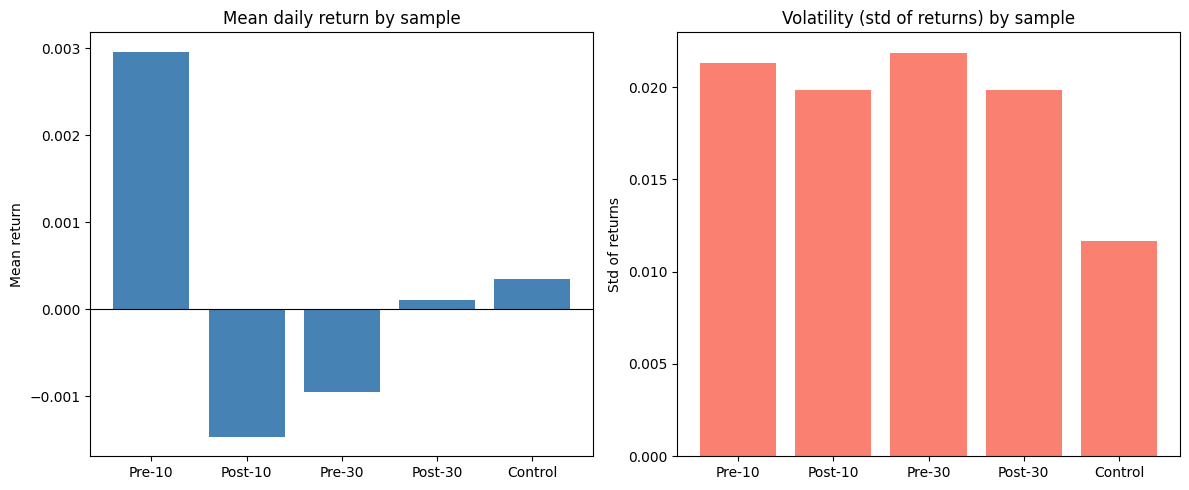

In [15]:
labels = ['Pre-10', 'Post-10', 'Pre-30', 'Post-30', 'Control']
means = [
    pre_10_df['sp500_return'].mean(),
    post_10_df['sp500_return'].mean(),
    pre_30_df['sp500_return'].mean(),
    post_30_df['sp500_return'].mean(),
    control_df['sp500_return'].mean(),
]
stds = [
    pre_10_df['sp500_return'].std(),
    post_10_df['sp500_return'].std(),
    pre_30_df['sp500_return'].std(),
    post_30_df['sp500_return'].std(),
    control_df['sp500_return'].std(),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(labels, means, color='steelblue')
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('Mean daily return by sample')
ax1.set_ylabel('Mean return')

ax2.bar(labels, stds, color='salmon')
ax2.set_title('Volatility (std of returns) by sample')
ax2.set_ylabel('Std of returns')

plt.tight_layout()
plt.show()

2. Histogram of S&P 500 returns (control vs pre-30)

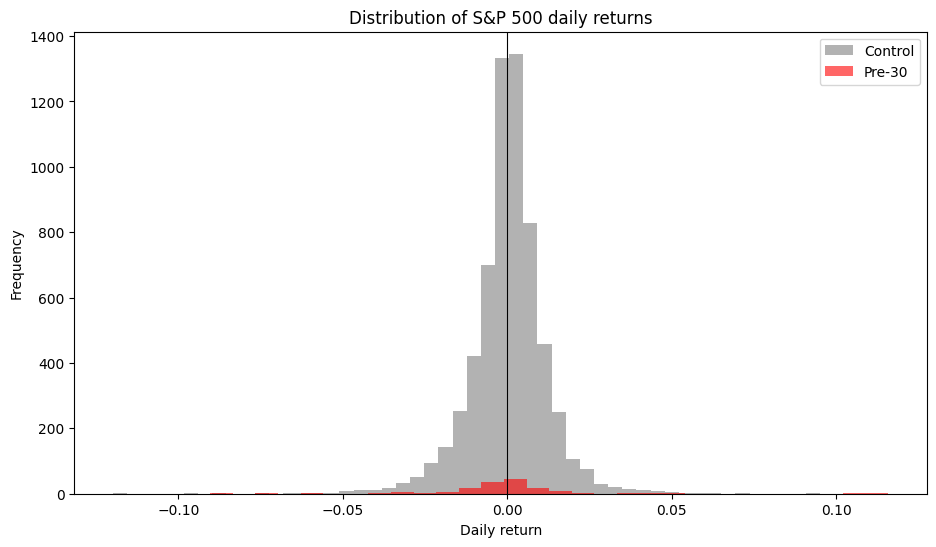

In [16]:
plt.figure(figsize=(11, 6))
plt.hist(control_df['sp500_return'].dropna(), bins=50, alpha=0.6, label='Control', color='gray')
plt.hist(pre_30_df['sp500_return'].dropna(), bins=30, alpha=0.6, label='Pre-30', color='red')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Distribution of S&P 500 daily returns')
plt.xlabel('Daily return')
plt.ylabel('Frequency')
plt.legend()
plt.show()

3. S&P 500 around each election

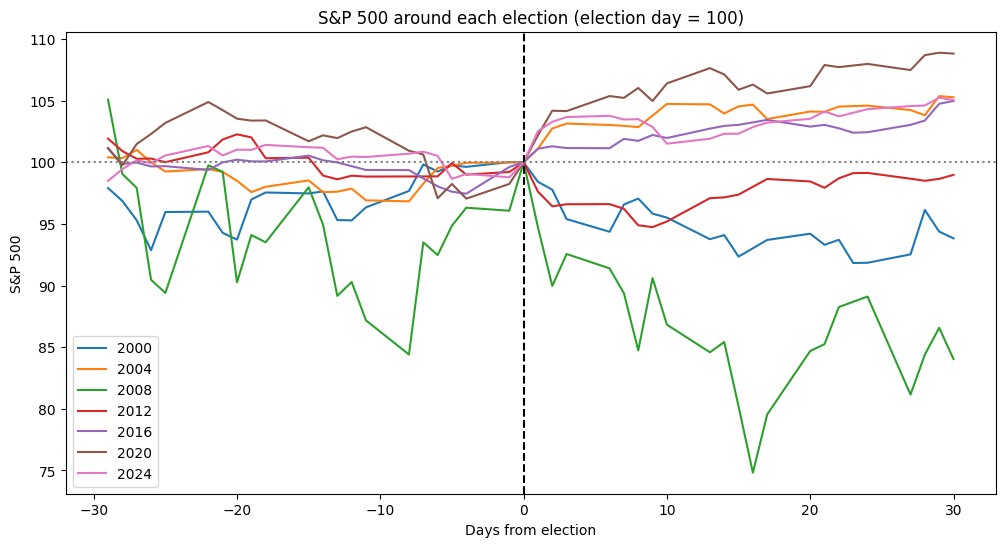

In [17]:
plt.figure(figsize=(12, 6))

for event_date in election_dates:
    temp = market_df.copy()
    temp['days'] = (temp['date'] - event_date).dt.days
    window = temp[(temp['days'] >= -30) & (temp['days'] <= 30)]
    if len(window) == 0:
        continue
    base = window['sp500_value'].iloc[(window['days'].abs()).argmin()]
    indexed = window['sp500_value'] / base * 100
    plt.plot(window['days'], indexed, label=str(event_date.year))

plt.axvline(0, color='black', linestyle='--')
plt.axhline(100, color='gray', linestyle=':')
plt.title('S&P 500 around each election (election day = 100)')
plt.xlabel('Days from election')
plt.ylabel('S&P 500')
plt.legend()
plt.show()

4. Republican vs Democratic post-30 mean returns and volatility


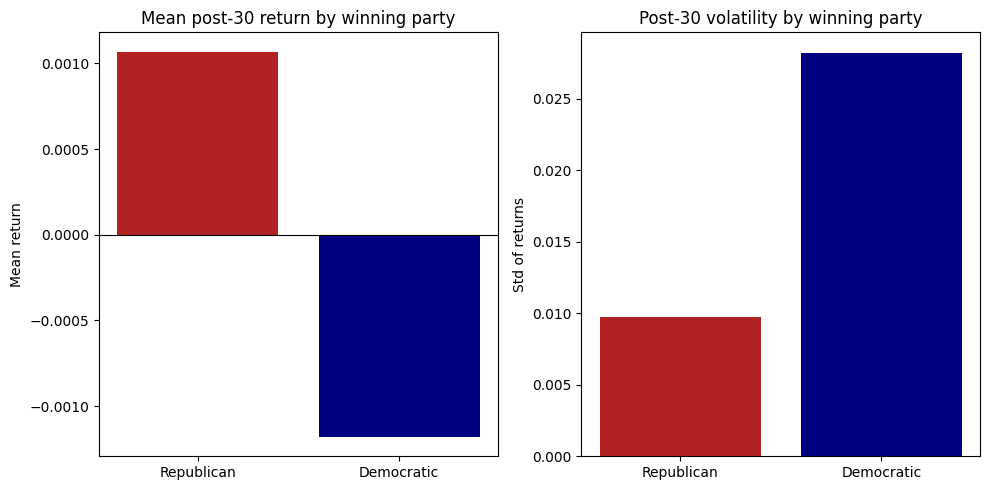

In [18]:
parties = ['Republican', 'Democratic']
mean_by_party = [rep_ret.mean(), dem_ret.mean()]
std_by_party = [rep_ret.std(), dem_ret.std()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.bar(parties, mean_by_party, color=['firebrick', 'navy'])
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('Mean post-30 return by winning party')
ax1.set_ylabel('Mean return')

ax2.bar(parties, std_by_party, color=['firebrick', 'navy'])
ax2.set_title('Post-30 volatility by winning party')
ax2.set_ylabel('Std of returns')

plt.tight_layout()
plt.show()


# Part 7: Machine Learning Models  

In this section I apply two ML models to predict S&P 500 daily returns in the event windows around presidential elections:

- Model 1 (Baseline): OLS Linear Regression
- Model 2: Random Forest Regressor

**Task definition:** Predict the next-day S&P 500 return using lagged market features and election context variables.



In [19]:
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm

## Step 1: Features construction

In [20]:
market_df['lag1_return']  = market_df['sp500_return'].shift(1)
market_df['lag2_return']  = market_df['sp500_return'].shift(2)
market_df['lag3_return']  = market_df['sp500_return'].shift(3)
market_df['lag5_return']  = market_df['sp500_return'].shift(5)
market_df['rolling_vol_5'] = market_df['sp500_return'].rolling(5).std()
market_df['vix_level']    = market_df['vix_value']

window_rows = []

for event_date in election_dates:
    temp = market_df.copy()
    temp['days_from_election'] = (temp['date'] - event_date).dt.days
    window = temp[
        (temp['days_from_election'] >= -30) &
        (temp['days_from_election'] <= 30) &
        (temp['days_from_election'] != 0)].copy()
    window['is_pre_election'] = (window['days_from_election'] < 0).astype(int)
    window['is_republican'] = int(party_map[event_date] == 'Republican')
    window['election_year']   = event_date.year
    window_rows.append(window)

ml_df = pd.concat(window_rows, ignore_index=True)
ml_df['target'] = ml_df['sp500_return']

feature_cols = [
    'lag1_return', 'lag2_return', 'lag3_return', 'lag5_return',
    'vix_level', 'vix_return', 'days_from_election',
    'is_pre_election', 'is_republican', 'rolling_vol_5'
]

ml_df = ml_df.dropna(subset=feature_cols + ['target'])
ml_df = ml_df.reset_index(drop=True)

print(f'ML dataset: {len(ml_df)} observations, {len(feature_cols)} features')
print(f'Target (sp500_return) — mean: {ml_df["target"].mean():.5f}, std: {ml_df["target"].std():.5f}')
ml_df[feature_cols + ['target']].describe().round(5)

ML dataset: 292 observations, 10 features
Target (sp500_return) — mean: -0.00042, std: 0.02084


,lag1_return,lag2_return,lag3_return,lag5_return,vix_level,vix_return,days_from_election,is_pre_election,is_republican,rolling_vol_5,target
count,292.00000,292.00000,292.00000,292.00000,292.00000,292.00000,292.00000,292.00000,292.00000,292.00000,292.00000
mean,-0.00022,-0.00034,-0.00069,-0.00095,25.74884,0.00329,-0.09247,0.49658,0.57534,0.01431,-0.00042
std,0.02097,0.02101,0.02068,0.01998,16.75368,0.07207,17.98420,0.50085,0.49514,0.01593,0.02084
min,-0.09035,-0.09035,-0.09035,-0.09035,11.79000,-0.24684,-29.00000,0.00000,0.00000,0.00145,-0.09035
25%,-0.00619,-0.00587,-0.00608,-0.00624,15.05000,-0.03357,-15.00000,0.00000,0.00000,0.00581,-0.00590
50%,0.00016,0.00016,0.00014,0.00003,19.09500,0.00000,1.00000,0.00000,1.00000,0.00832,0.00016
75%,0.00589,0.00575,0.00552,0.00540,27.25250,0.04024,15.00000,1.00000,1.00000,0.01338,0.00561
max,0.11580,0.11580,0.11580,0.11580,80.86000,0.31143,30.00000,1.00000,1.00000,0.08158,0.11580


## Step 2: Train / Validation / Test Split

Elections are ordered chronologically:
- **Train:** 2000, 2004, 2008, 2012 elections (first ~60%)
- **Validation:** 2016 election (tune hyperparameters here)
- **Test:** 2020, 2024 elections (final evaluation — never touched during training)



In [21]:
train_mask = ml_df['election_year'].isin([2000, 2004, 2008, 2012])
val_mask   = ml_df['election_year'].isin([2016])
test_mask  = ml_df['election_year'].isin([2020, 2024])

X_train = ml_df.loc[train_mask, feature_cols]
y_train = ml_df.loc[train_mask, 'target']

X_val   = ml_df.loc[val_mask, feature_cols]
y_val   = ml_df.loc[val_mask, 'target']

X_test  = ml_df.loc[test_mask, feature_cols]
y_test  = ml_df.loc[test_mask, 'target']

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

print(f'Train: {len(X_train)} obs')
print(f'Validation: {len(X_val)} obs')
print(f'Test: {len(X_test)} obs')

Train: 166 obs
Validation: 42 obs
Test: 84 obs


## Step 3: Model I. OLS Linear Regression (Baseline)


In [22]:
X_train_sm = sm.add_constant(X_train)
ols_model  = sm.OLS(y_train, X_train_sm).fit()
X_test_sm = sm.add_constant(X_test, has_constant='add')
y_pred_ols = ols_model.predict(X_test_sm)

mae_ols  = mean_absolute_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
r2_ols   = r2_score(y_test, y_pred_ols)
mape_ols = np.mean(np.abs((y_test - y_pred_ols) / (np.abs(y_test) + 1e-8))) * 100

print('OLS Test  Performance')
print(f'  MAE:  {mae_ols:.6f}')
print(f'  RMSE: {rmse_ols:.6f}')
print(f'  R²:   {r2_ols:.4f}')
print(f'  MAPE: {mape_ols:.2f}%')

OLS Test  Performance
  MAE:  0.009028
  RMSE: 0.012255
  R²:   -0.6325
  MAPE: 1101.51%


## Step 4: Model II. Random Forest Regressor



In [23]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 7, None],
    'min_samples_leaf':  [3, 5, 10],
    'max_features':      ['sqrt', 0.5]
}
rf_base = RandomForestRegressor(random_state=42)

kf = KFold(n_splits=5, shuffle=False)

grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print('Best hyperparameters found:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):.6f}')

Best hyperparameters found:
  max_depth: 7
  max_features: 0.5
  min_samples_leaf: 3
  n_estimators: 100
Best CV RMSE: 0.017561


In [24]:
best_rf = RandomForestRegressor(**grid_search.best_params_, random_state=42)
best_rf.fit(X_trainval, y_trainval)

y_pred_rf = best_rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / (np.abs(y_test) + 1e-8))) * 100

print('Random Forest Test  Performance')
print(f'  MAE:  {mae_rf:.6f}')
print(f'  RMSE: {rmse_rf:.6f}')
print(f'  R²:   {r2_rf:.4f}')
print(f'  MAPE: {mape_rf:.2f}%')

Random Forest Test  Performance
  MAE:  0.004941
  RMSE: 0.006803
  R²:   0.4969
  MAPE: 510.42%


## Step 5: Validation (both models)


In [25]:
kf = KFold(n_splits=5, shuffle=False)

ols_sk = LinearRegression()
cv_ols = cross_val_score(ols_sk, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
cv_ols_rmse = np.sqrt(-cv_ols)

rf_cv_model = RandomForestRegressor(**grid_search.best_params_, random_state=42)
cv_rf = cross_val_score(rf_cv_model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
cv_rf_rmse = np.sqrt(-cv_rf)

print('5-Fold CV RMSE (training data):')
print(f'  OLS: {cv_ols_rmse.mean():.6f}  (+/- {cv_ols_rmse.std():.6f})')
print(f'  RF:  {cv_rf_rmse.mean():.6f}  (+/- {cv_rf_rmse.std():.6f})')

5-Fold CV RMSE (training data):
  OLS: 0.014737  (+/- 0.005413)
  RF:  0.015430  (+/- 0.008384)


## Step 6: Results Summary Table


In [26]:
results = pd.DataFrame({
    'Model': ['OLS (Baseline)', 'Random Forest'],
    'CV RMSE (train)': [f'{cv_ols_rmse.mean():.6f}', f'{cv_rf_rmse.mean():.6f}'],
    'Test MAE':  [f'{mae_ols:.6f}',  f'{mae_rf:.6f}'],
    'Test RMSE': [f'{rmse_ols:.6f}', f'{rmse_rf:.6f}'],
    'Test R²':   [f'{r2_ols:.4f}',   f'{r2_rf:.4f}'],
    'Test MAPE': [f'{mape_ols:.2f}%', f'{mape_rf:.2f}%']
})

print(results.to_string(index=False))

         Model CV RMSE (train) Test MAE Test RMSE Test R² Test MAPE
OLS (Baseline)        0.014737 0.009028  0.012255 -0.6325  1101.51%
 Random Forest        0.015430 0.004941  0.006803  0.4969   510.42%


## Step 7: Visualizations

Four plots:
1. Actual vs Predicted returns, OLS vs RF
2. Residuals plot (OLS)
3. Error comparison (MAE / RMSE bar chart)
4. Feature importance (Random Forest)

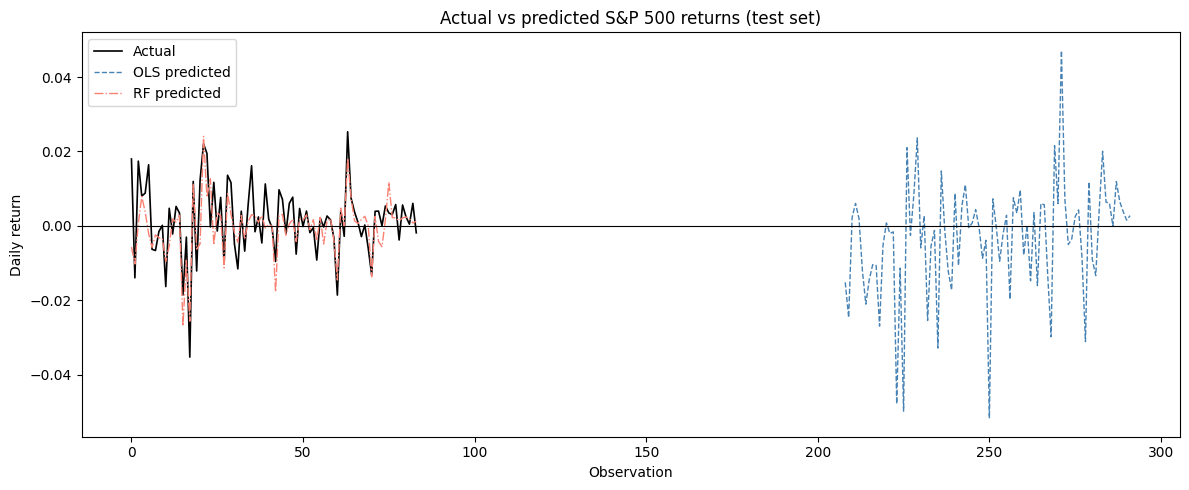

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(y_test.values, color='black', linewidth=1.2, label='Actual')
plt.plot(y_pred_ols, color='steelblue', linewidth=1, linestyle='--', label='OLS predicted')
plt.plot(y_pred_rf,  color='salmon',    linewidth=1, linestyle='-.', label='RF predicted')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Actual vs predicted S&P 500 returns (test set)')
plt.xlabel('Observation')
plt.ylabel('Daily return')
plt.legend()
plt.tight_layout()
plt.show()

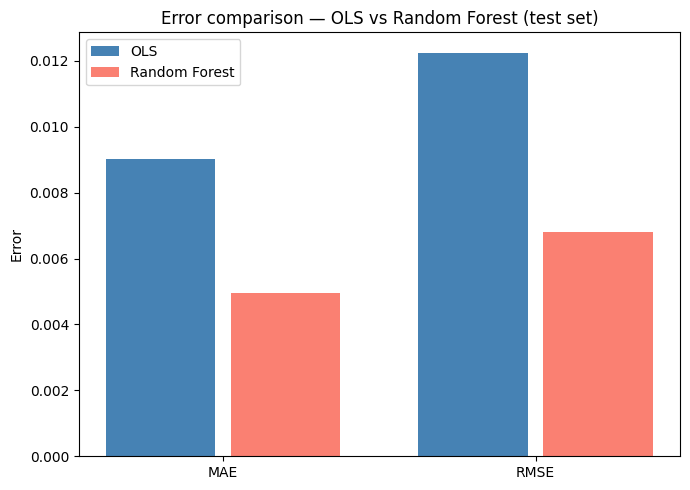

In [28]:
labels = ['MAE', 'RMSE']
ols_scores = [mae_ols, rmse_ols]
rf_scores  = [mae_rf,  rmse_rf]

x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - 0.2, ols_scores, 0.35, color='steelblue', label='OLS')
ax.bar(x + 0.2, rf_scores,  0.35, color='salmon',    label='Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Error comparison — OLS vs Random Forest (test set)')
ax.set_ylabel('Error')
ax.legend()
plt.tight_layout()
plt.show()

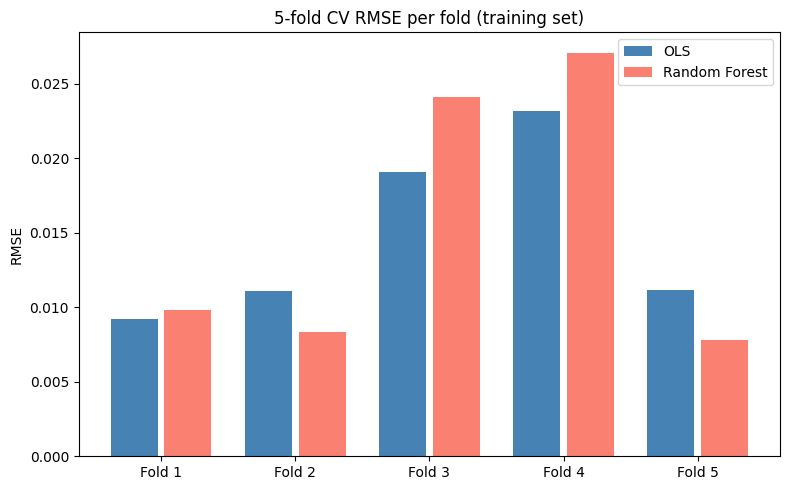

In [29]:
folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
x = np.arange(5)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - 0.2, cv_ols_rmse, 0.35, color='steelblue', label='OLS')
ax.bar(x + 0.2, cv_rf_rmse,  0.35, color='salmon',    label='Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_title('5-fold CV RMSE per fold (training set)')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.show()

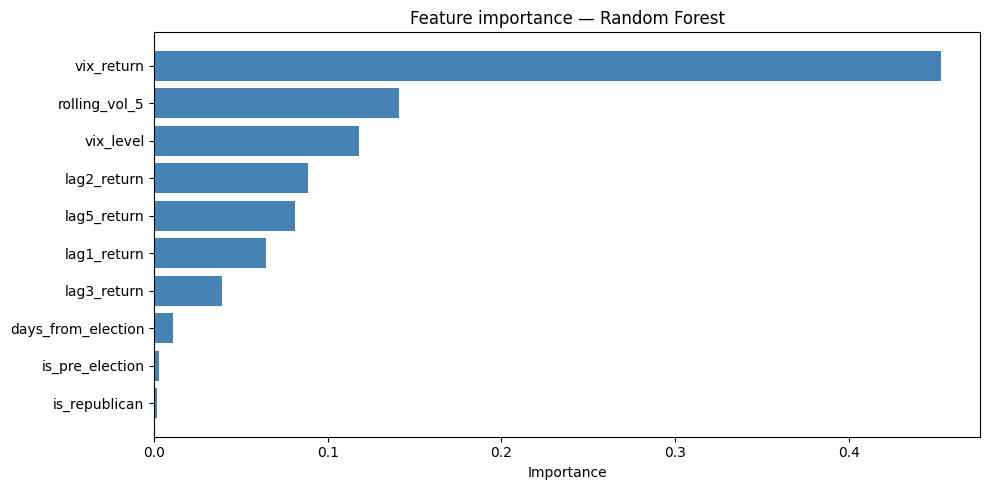

In [30]:
sorted_idx = np.argsort(best_rf.feature_importances_)

plt.figure(figsize=(10, 5))
plt.barh(
    [feature_cols[i] for i in sorted_idx],
    best_rf.feature_importances_[sorted_idx],
    color='steelblue'
)
plt.title('Feature importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [31]:
market_df.to_csv('sp500_vix_data.csv', index=False)
elections_df.to_csv('elections_data.csv', index=False)